In [1]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from sklearn.datasets import fetch_olivetti_faces

In [3]:
from sklearn.model_selection import cross_val_score, train_test_split

In [5]:
from sklearn.naive_bayes import GaussianNB

In [20]:
data = fetch_olivetti_faces(shuffle=True, random_state=42)

In [21]:
import matplotlib.pyplot as plt


In [22]:
data

{'data': array([[0.1983471 , 0.23553719, 0.35123968, ..., 0.06198347, 0.12809917,
         0.09090909],
        [0.18595041, 0.12809917, 0.11570248, ..., 0.19008264, 0.2107438 ,
         0.2107438 ],
        [0.5082645 , 0.60330576, 0.6198347 , ..., 0.33471075, 0.3429752 ,
         0.3429752 ],
        ...,
        [0.61157024, 0.6446281 , 0.6570248 , ..., 0.17768595, 0.2107438 ,
         0.2231405 ],
        [0.28512397, 0.29338843, 0.29752067, ..., 0.53305787, 0.53305787,
         0.5371901 ],
        [0.3264463 , 0.1446281 , 0.2603306 , ..., 0.14049587, 0.30165288,
         0.1570248 ]], shape=(400, 4096), dtype=float32),
 'images': array([[[0.1983471 , 0.23553719, 0.35123968, ..., 0.5041322 ,
          0.5289256 , 0.5289256 ],
         [0.19421488, 0.24380165, 0.36363637, ..., 0.5041322 ,
          0.5165289 , 0.5289256 ],
         [0.1983471 , 0.2520661 , 0.35950413, ..., 0.5123967 ,
          0.5123967 , 0.5247934 ],
         ...,
         [0.35950413, 0.57024795, 0.55785125, ...

In [23]:
X = data.data
Y = data.target

In [24]:
X_Train, X_Test, Y_Train, Y_Test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42
)

In [25]:
model = GaussianNB().fit(X_Train, Y_Train)

In [26]:
pred = model.predict(X_Test)

In [27]:
accuracy_score(pred, Y_Test)

0.8083333333333333

In [30]:
print(classification_report(pred, Y_Test, zero_division=1))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00         2
           2       0.67      0.33      0.44         6
           3       0.00      1.00      0.00         0
           4       0.50      1.00      0.67         2
           5       1.00      1.00      1.00         2
           7       0.75      1.00      0.86         3
           8       0.67      1.00      0.80         2
           9       0.75      1.00      0.86         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         1
          12       1.00      0.40      0.57        10
          13       0.80      1.00      0.89         4
          14       0.40      1.00      0.57         2
          15       1.00      0.67      0.80         3
          16       0.67      1.00      0.80         2
          17       1.00      1.00      1.00         3
          18       1.00    

In [31]:
confusion_matrix(pred, Y_Test)

array([[2, 0, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 0, 0, 0],
       [0, 0, 2, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 3, 0],
       [0, 0, 1, ..., 0, 0, 5]], shape=(38, 38))

In [32]:
cross_val_score(model, X, Y, cv=5).mean()*100


np.float64(87.25)

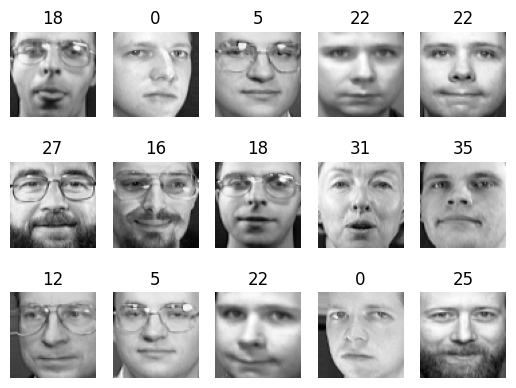

In [35]:
fig,ax = plt.subplots(3,5)
for i in range(15):
    ax.ravel()[i].imshow(X_Test[i].reshape(64,64), cmap = 'grey')
    ax.ravel()[i].set_title(pred[i])
    ax.ravel()[i].axis('off')
plt.show()